# Reward functions vs policies (ICU-Sepsis)

Train tabular / deep RL baselines under different **tabular rewards** $r(s,a,s')$ while reporting a **common** evaluation metric: **hospital survival**, $\mathbb{P}(S_{T}=s^{\mathrm{surv}})$, from the terminal discrete state (same as the packaged binary outcome), independent of the training reward scale.

Each section below states the reward definition, then runs value iteration + the same algorithm suite as ``train_mdp_policies.ipynb``.


In [1]:
from __future__ import annotations

from pathlib import Path
from types import SimpleNamespace
import os
import sys

import gymnasium as gym
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
POLICIES_ROOT = PROJECT_ROOT / "policies"
ICU_SEPSIS_PACKAGE_ROOT = PROJECT_ROOT / "icu_sepsis" / "icu_sepsis"
ICU_SEPSIS_HELPERS_ROOT = PROJECT_ROOT / "icu_sepsis" / "icu_sepsis_helpers"

for path in (PROJECT_ROOT, POLICIES_ROOT, ICU_SEPSIS_PACKAGE_ROOT, ICU_SEPSIS_HELPERS_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.chdir(POLICIES_ROOT)

import icu_sepsis  # noqa: F401
from icu_sepsis_helpers.utils.mdp import value_iteration
from icu_sepsis.utils.reward_specs import (
    SURVIVAL_PACKAGED,
    build_reward_matrix,
    episode_survived,
)
from src.algos.dqn import run_dqn
from src.algos.ppo import run_ppo
from src.algos.qlearning import run_qlearning
from src.algos.sac import run_sac
from src.algos.sarsa import run_sarsa


def make_args(**kwargs):
    return SimpleNamespace(**kwargs)


TRAIN_EPISODES = 3000
EVAL_EPISODES = 2000
BASE_SEED = 7
ALGORITHMS = ["qlearning", "sarsa", "dqn", "ppo", "sac"]

ALGO_RUNNERS = {
    "qlearning": run_qlearning,
    "sarsa": run_sarsa,
    "dqn": run_dqn,
    "ppo": run_ppo,
    "sac": run_sac,
}

ALGO_CONFIGS = {
    "qlearning": dict(seed=BASE_SEED + 0, num_envs=1, max_episodes=TRAIN_EPISODES, learning_rate=0.0025, buffer_size=1, gamma=1.0, batch_size=1, start_e=1.0, end_e=0.001, exploration_fraction=0.1),
    "sarsa": dict(seed=BASE_SEED + 1, num_envs=1, max_episodes=TRAIN_EPISODES, learning_rate=0.0025, buffer_size=1, gamma=0.99, batch_size=1, start_e=1.0, end_e=0.05, exploration_fraction=0.3),
    "dqn": dict(seed=BASE_SEED + 2, num_envs=1, max_episodes=TRAIN_EPISODES, learning_rate=2.5e-4, buffer_size=2000, gamma=0.99, tau=1.0, target_network_frequency=100, batch_size=32, start_e=1.0, end_e=0.05, exploration_fraction=0.3, learning_starts=100, train_frequency=4),
    "ppo": dict(seed=BASE_SEED + 3, num_envs=1, learning_rate=2.5e-4, num_steps=128, max_episodes=TRAIN_EPISODES, num_minibatches=4, gamma=1.0, gae_lambda=0.95, update_epochs=4, norm_adv=True, clip_coef=0.2, clip_vloss=True, ent_coef=1.0, vf_coef=0.5, max_grad_norm=0.5, target_kl=None),
    "sac": dict(seed=BASE_SEED + 4, num_envs=1, max_episodes=TRAIN_EPISODES, buffer_size=5000, gamma=0.99, tau=1.0, batch_size=32, learning_starts=100, policy_lr=3e-4, q_lr=3e-4, update_frequency=4, target_network_frequency=200, alpha=0.2, autotune=True, target_entropy_scale=0.89),
}


def encode_single_state(state: int, n_states: int) -> torch.Tensor:
    return F.one_hot(torch.tensor([state]), num_classes=n_states).float()


def single_action_mask(info: dict, n_actions: int) -> torch.Tensor:
    mask = torch.zeros((1, n_actions), dtype=torch.float32)
    mask[0, info["admissible_actions"]] = 1.0
    return mask


def greedy_policy_from_result(result):
    model = result["agent"]
    algo = result["algo"]
    n_states = result["n_states"]
    n_actions = result["n_actions"]

    def policy(state: int, info: dict) -> int:
        obs = encode_single_state(int(state), n_states)
        mask = single_action_mask(info, n_actions)
        with torch.no_grad():
            if algo in {"qlearning", "sarsa", "dqn"}:
                q_values = model(obs, mask)
                return int(torch.argmax(q_values, dim=1).item())
            logits = model.actor(obs)
            logits = logits - ((1 - mask) * 1e10)
            return int(torch.argmax(logits, dim=1).item())

    return policy


def _gym_kw(reward_spec, reward_params):
    kw = {}
    if reward_spec is not None:
        kw["reward_spec"] = reward_spec
    if reward_params is not None:
        kw["reward_params"] = reward_params
    return kw


def rollout_policy(policy_name: str, policy_fn, reset_seeds: np.ndarray, reward_spec, reward_params, state_survival: int):
    env = gym.make("Sepsis/ICU-Sepsis-v2", **_gym_kw(reward_spec, reward_params))
    traces = []
    try:
        for reset_seed in reset_seeds:
            state, info = env.reset(seed=int(reset_seed))
            episode_rng = np.random.default_rng(int(reset_seed))
            done = False
            total_reward = 0.0
            episode_length = 0
            trace = {
                "policy": policy_name,
                "reset_seed": int(reset_seed),
                "states": [int(state)],
                "actions": [],
                "rewards": [],
            }
            while not done:
                try:
                    action = int(policy_fn(int(state), info, episode_rng))
                except TypeError:
                    action = int(policy_fn(int(state), info))
                next_state, reward, terminated, truncated, info = env.step(action)
                state = int(next_state)
                total_reward += float(reward)
                episode_length += 1
                trace["actions"].append(action)
                trace["rewards"].append(float(reward))
                trace["states"].append(state)
                done = bool(terminated or truncated)
            trace["episode_return"] = total_reward
            trace["episode_length"] = episode_length
            trace["survived"] = episode_survived(trace["states"][-1], state_survival)
            traces.append(trace)
    finally:
        env.close()
    return traces


def summarize_rollouts(policy_name: str, traces):
    returns = np.array([t["episode_return"] for t in traces], dtype=float)
    lengths = np.array([t["episode_length"] for t in traces], dtype=float)
    survived = np.array([float(t["survived"]) for t in traces], dtype=float)
    n = max(1, len(returns))
    mean_return = float(returns.mean())
    std_return = float(returns.std(ddof=0))
    stderr_return = float(std_return / np.sqrt(n))
    ci95_halfwidth = float(1.96 * stderr_return)
    survival_rate = float(survived.mean())
    stderr_survival = float(np.sqrt(max(1e-12, survival_rate * (1 - survival_rate)) / n))
    return {
        "policy": policy_name,
        "n_episodes": int(n),
        "mean_return": mean_return,
        "std_return": std_return,
        "stderr_return": stderr_return,
        "ci95_return": ci95_halfwidth,
        "mean_length": float(lengths.mean()),
        "survival_rate": survival_rate,
        "stderr_survival": stderr_survival,
    }


def train_algorithm(name: str, reward_spec, reward_params):
    cfg = dict(ALGO_CONFIGS[name])
    if reward_spec is not None:
        cfg["reward_spec"] = reward_spec
    if reward_params is not None:
        cfg["reward_params"] = reward_params
    args = make_args(**cfg)
    print(f"training {name} (reward_spec={reward_spec!r})...")
    result = ALGO_RUNNERS[name](args, use_tensorboard=False, use_wandb=False, return_agent=True)
    result["name"] = name
    result["algo"] = name
    return result


def run_reward_experiment(reward_spec, reward_params=None, *, table_label: str):
    """Train all baselines + value iteration for one reward; evaluate with common survival_rate."""
    ref = gym.make("Sepsis/ICU-Sepsis-v2", **_gym_kw(reward_spec, reward_params))
    mdp = ref.unwrapped
    tx = np.asarray(mdp.dynamics["tx_mat"])
    packaged_r = np.asarray(mdp.dynamics["r_mat"])
    sofa = np.asarray(mdp.sofa_scores)
    centers = np.asarray(mdp.state_cluster_centers)
    gamma = float(mdp.gamma)
    expert_pi = np.asarray(mdp.expert_policy)
    state_survival = int(mdp.state_survival)
    n_states = int(mdp.num_states)
    n_actions = int(mdp.num_actions)
    ref.close()

    spec_for_build = reward_spec if reward_spec is not None else SURVIVAL_PACKAGED
    r_mat = build_reward_matrix(tx, sofa, centers, packaged_r, spec_for_build, reward_params or {})
    optimal_actions, _ = value_iteration(tx, r_mat, gamma)

    results = [train_algorithm(name, reward_spec, reward_params) for name in ALGORITHMS]

    reset_seeds = BASE_SEED + np.arange(EVAL_EPISODES, dtype=np.int64)
    evaluation_rows = []

    random_policy = lambda state, info, rng: int(rng.choice(info["admissible_actions"]))
    expert_policy = lambda state, info, rng: int(rng.choice(n_actions, p=expert_pi[state]))
    optimal_policy = lambda state, info, rng=None: int(optimal_actions[state])

    for name, policy_fn in [
        ("random", random_policy),
        ("expert", expert_policy),
        ("optimal", optimal_policy),
    ]:
        traces = rollout_policy(name, policy_fn, reset_seeds, reward_spec, reward_params, state_survival)
        evaluation_rows.append(summarize_rollouts(name, traces))

    for result in results:
        policy_fn = greedy_policy_from_result(result)
        traces = rollout_policy(result["name"], policy_fn, reset_seeds, reward_spec, reward_params, state_survival)
        evaluation_rows.append(summarize_rollouts(result["name"], traces))

    eval_df = pd.DataFrame(evaluation_rows).sort_values("mean_return", ascending=False).reset_index(drop=True)
    eval_df.insert(0, "reward", table_label)
    print(eval_df.to_string(index=False))
    return eval_df


ALL_EVAL_FRAMES = []



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


### Packaged survival reward (default)

Let $s^{\mathrm{death}}$, $s^{\mathrm{surv}}$, $s_\infty$ be the three absorbing states. The shipped ``dynamics.npz`` uses **sparse** rewards: transitions into transient states have $r=0$; the first step into an absorbing state yields the cohort outcome (here: $+1$ if $s'=s^{\mathrm{surv}}$, $0$ if $s'=s^{\mathrm{death}}$).

$$r(s,a,s') = \begin{cases} +1 & s' = s^{\mathrm{surv}} \\ 0 & s' = s^{\mathrm{death}} \text{ or } s_\infty \\ 0 & \text{otherwise} \end{cases}$$

Training uses ``reward_spec=None`` (loads ``r_mat`` unchanged).


In [2]:
ALL_EVAL_FRAMES.append(run_reward_experiment(None, None, table_label='Packaged survival (default)'))

Value Iteration:   0%|          | 149/50000 [00:06<38:45, 21.44it/s]


training qlearning (reward_spec=None)...
Number of States: 716, Number of actions: 25
Mean Q Value: 0.0
SPS: 1356, Episode: 93, Step: 1000, Return: 1.0, Episode length: 3
Steps: 1000
Mean Q Value: 0.06610497832298279
SPS: 1465, Episode: 191, Step: 2000, Return: 1.0, Episode length: 7
Steps: 2000
Mean Q Value: 0.0
SPS: 1481, Episode: 311, Step: 3000, Return: 1.0, Episode length: 11
Steps: 3000
Mean Q Value: 0.07675779610872269
SPS: 1492, Episode: 431, Step: 4000, Return: 0.0, Episode length: 9
Steps: 4000
Mean Q Value: 0.07701054960489273
SPS: 1486, Episode: 549, Step: 5000, Return: 1.0, Episode length: 2
Steps: 5000
Mean Q Value: 0.045855578035116196
SPS: 1489, Episode: 647, Step: 6000, Return: 1.0, Episode length: 20
Steps: 6000
Mean Q Value: 0.213080495595932
SPS: 1496, Episode: 769, Step: 7000, Return: 1.0, Episode length: 18
Steps: 7000
Mean Q Value: 0.21456821262836456
SPS: 1500, Episode: 886, Step: 8000, Return: 1.0, Episode length: 1
Steps: 8000
Mean Q Value: 0.2003527283668518


/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/policies/src/utils/utils.py:111: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  actions = torch.tensor(batch.action, dtype=torch.int64).reshape((batch_size, -1))


SPS: 5028, Episode: 18, Step: 200, Return: 1.0, Episode length: 7
SPS: 4337, Episode: 30, Step: 300, Return: 1.0, Episode length: 30
SPS: 4067, Episode: 40, Step: 400, Return: 1.0, Episode length: 17
SPS: 3935, Episode: 44, Step: 500, Return: 1.0, Episode length: 17
SPS: 3838, Episode: 55, Step: 600, Return: 1.0, Episode length: 1
SPS: 3765, Episode: 63, Step: 700, Return: 1.0, Episode length: 15
SPS: 3706, Episode: 72, Step: 800, Return: 1.0, Episode length: 9
SPS: 3649, Episode: 91, Step: 900, Return: 0.0, Episode length: 3
SPS: 3606, Episode: 100, Step: 1000, Return: 1.0, Episode length: 4
SPS: 3566, Episode: 108, Step: 1100, Return: 1.0, Episode length: 23
SPS: 3528, Episode: 120, Step: 1200, Return: 0.0, Episode length: 12
SPS: 3506, Episode: 126, Step: 1300, Return: 1.0, Episode length: 27
SPS: 3484, Episode: 135, Step: 1400, Return: 1.0, Episode length: 19
SPS: 3470, Episode: 147, Step: 1500, Return: 1.0, Episode length: 12
SPS: 3452, Episode: 159, Step: 1600, Return: 1.0, Episo

### SOFA penalty on the next state

Let $\mathrm{SOFA}(s)$ be the mean SOFA score for cluster $s$, $S_{\max} = \max_{s \text{ transient}} \mathrm{SOFA}(s)$, and $\lambda>0$. Transient-to-transient transitions are penalized in proportion to illness severity of the **entered** state; absorbing rewards stay packaged.

$$r(s,a,s') = \begin{cases} -\lambda\,\dfrac{\mathrm{SOFA}(s')}{S_{\max}} & s,s' \text{ transient} \\ r_{\text{packaged}}(s,a,s') & \text{otherwise} \end{cases}$$


In [3]:
ALL_EVAL_FRAMES.append(run_reward_experiment('sofa_next', {'lambda': 0.05}, table_label='sofa_next'))

Value Iteration:   0%|          | 122/50000 [00:05<36:36, 22.71it/s]


training qlearning (reward_spec='sofa_next')...
Number of States: 716, Number of actions: 25
Mean Q Value: 0.0
SPS: 1597, Episode: 91, Step: 1000, Return: 0.9848723435655253, Episode length: 2
Steps: 1000
Mean Q Value: 0.05030228570103645
SPS: 1583, Episode: 193, Step: 2000, Return: 0.9196586355137008, Episode length: 7
Steps: 2000
Mean Q Value: 0.0
SPS: 1561, Episode: 299, Step: 3000, Return: 0.9264425564947386, Episode length: 3
Steps: 3000
Mean Q Value: -0.01835920289158821
SPS: 1544, Episode: 410, Step: 4000, Return: 0.8540413195894965, Episode length: 8
Steps: 4000
Mean Q Value: -0.018159860745072365
SPS: 1533, Episode: 511, Step: 5000, Return: 0.6531051525740329, Episode length: 22
Steps: 5000
Mean Q Value: 0.07928305119276047
SPS: 1524, Episode: 616, Step: 6000, Return: -0.4742354586875353, Episode length: 23
Steps: 6000
Mean Q Value: 0.069536492228508
SPS: 1509, Episode: 730, Step: 7000, Return: 0.8240979514520631, Episode length: 15
Steps: 7000
Mean Q Value: 0.1324979513883590

### SOFA improvement / worsening (step delta)

Penalize increases in SOFA along the path (reward clinical stabilization). With scale $\Delta = \max_{s \text{ transient}} \mathrm{SOFA}(s) - \min(\cdot)$:

$$r(s,a,s') = \begin{cases} -\lambda\,\dfrac{\mathrm{SOFA}(s')-\mathrm{SOFA}(s)}{\Delta} & s,s' \text{ transient} \\ r_{\text{packaged}}(s,a,s') & \text{otherwise} \end{cases}$$


In [4]:
ALL_EVAL_FRAMES.append(run_reward_experiment('sofa_delta', {'lambda': 0.05}, table_label='sofa_delta'))


Value Iteration:   0%|          | 149/50000 [00:07<39:47, 20.88it/s]


training qlearning (reward_spec='sofa_delta')...
Number of States: 716, Number of actions: 25
Mean Q Value: 0.0
SPS: 1610, Episode: 95, Step: 1000, Return: 1.009826183194883, Episode length: 2
Steps: 1000
Mean Q Value: -0.005057796370238066
SPS: 1573, Episode: 196, Step: 2000, Return: 0.9947534972890163, Episode length: 7
Steps: 2000
Mean Q Value: 0.13782280683517456
SPS: 1503, Episode: 296, Step: 3000, Return: 1.0141183923576982, Episode length: 35
Steps: 3000
Mean Q Value: 0.11881629377603531
SPS: 1481, Episode: 402, Step: 4000, Return: 1.0120535871564367, Episode length: 8
Steps: 4000
Mean Q Value: 0.05482357367873192
SPS: 1483, Episode: 507, Step: 5000, Return: -0.02932975845543293, Episode length: 19
Steps: 5000
Mean Q Value: 0.015005761757493019
SPS: 1473, Episode: 607, Step: 6000, Return: -0.000157099184395648, Episode length: 11
Steps: 6000
Mean Q Value: 0.15279561281204224
SPS: 1477, Episode: 729, Step: 7000, Return: 0.975983586765259, Episode length: 3
Steps: 7000
Mean Q Valu

### APACHE-like **severity proxy** from cluster centroids

True APACHE-II is not stored per discrete state in the bundled assets. We use a **monotone severity index** from cluster centers $c_s \in \mathbb{R}^D$: hinge above the per-feature median $\tilde{c}_d = \mathrm{median}_s\, c_{s,d}$,

$$\psi(s') = \frac{1}{D}\sum_{d=1}^{D} \max(0,\; c_{s',d}-\tilde{c}_d),\qquad \psi_{\max}=\max_{s'}\psi(s')$$

$$r(s,a,s') = \begin{cases} -\lambda\,\dfrac{\psi(s')}{\psi_{\max}} & s,s' \text{ transient} \\ r_{\text{packaged}}(s,a,s') & \text{otherwise} \end{cases}$$


In [5]:
# Plot moved to the end, after the combined table.
# (legacy plot kept for backward compatibility if this cell is executed.)
import matplotlib.pyplot as plt

plot_df = summary_df.copy() if "summary_df" in globals() else pd.DataFrame(columns=["policy", "reward", "survival_rate"])
policy_order = ["optimal", "dqn", "ppo", "qlearning", "sac", "expert", "random", "sarsa"]
_default_reward_order = [
    "Packaged survival (default)",
    "sofa_next",
    "sofa_delta",
    "severity_proxy",
    "death_prob_dense",
    "coper_composite",
]
if "reward_order" not in globals():
    reward_order = list(_default_reward_order)
if len(plot_df) > 0 and "reward" in plot_df.columns:
    present_r = set(plot_df["reward"].dropna().astype(str))
    reward_order = [r for r in reward_order if r in present_r] + sorted(
        present_r - set(reward_order), key=str
    )

if len(plot_df) == 0:
    print(
        "Skipping legacy survival plot: `summary_df` is empty or not built yet. "
        "Run the reward experiment cells, then the combined `summary_df` cell."
    )
else:
    plot_df["policy"] = pd.Categorical(plot_df["policy"], categories=policy_order, ordered=True)
    plot_df["reward"] = pd.Categorical(plot_df["reward"], categories=reward_order, ordered=True)
    plot_df = plot_df.sort_values(["policy", "reward"])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

    for policy, group in plot_df.groupby("policy", observed=False):
        if group["survival_rate"].notna().any():
            axes[0].plot(group["reward"], group["survival_rate"], marker="o", linewidth=1.8, label=policy)

    axes[0].set_title("Survival rate by reward function")
    axes[0].set_xlabel("Reward function")
    axes[0].set_ylabel("Survival rate")
    axes[0].set_ylim(0.70, 0.90)
    axes[0].tick_params(axis="x", rotation=25)
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    _pv = plot_df.pivot(index="policy", columns="reward", values="survival_rate")
    _prow = [p for p in policy_order if p in _pv.index]
    _pcol = [r for r in reward_order if r in _pv.columns]
    heat = _pv.reindex(index=_prow, columns=_pcol)
    im = axes[1].imshow(heat.values, aspect="auto", cmap="viridis", vmin=float(np.nanmin(heat.values)), vmax=float(np.nanmax(heat.values)))
    axes[1].set_title("Survival-rate heatmap")
    axes[1].set_xticks(range(len(_pcol)))
    axes[1].set_xticklabels(_pcol, rotation=25, ha="right")
    axes[1].set_yticks(range(len(_prow)))
    axes[1].set_yticklabels(_prow)

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat.values[i, j]
            axes[1].text(j, i, f"{val:.3f}", ha="center", va="center", color="white", fontsize=8)

    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label("survival_rate")

    plt.show()

Skipping legacy survival plot: `summary_df` is empty or not built yet. Run the reward experiment cells, then the combined `summary_df` cell.


In [ ]:
ALL_EVAL_FRAMES.append(run_reward_experiment('severity_proxy', {'lambda': 0.05}, table_label='severity_proxy'))

Value Iteration:   0%|          | 124/50000 [00:05<38:04, 21.83it/s]


training qlearning (reward_spec='severity_proxy')...
Number of States: 716, Number of actions: 25
Mean Q Value: 0.0
SPS: 1505, Episode: 91, Step: 1000, Return: 0.9953247672253339, Episode length: 2
Steps: 1000
Mean Q Value: 0.0
SPS: 1476, Episode: 182, Step: 2000, Return: 0.9262865545164166, Episode length: 7
Steps: 2000
Mean Q Value: 0.0
SPS: 1441, Episode: 283, Step: 3000, Return: 0.907602535790301, Episode length: 11
Steps: 3000
Mean Q Value: 0.07304050773382187
SPS: 1419, Episode: 381, Step: 4000, Return: -0.13343286002329158, Episode length: 14
Steps: 4000
Mean Q Value: -0.008221405558288097
SPS: 1401, Episode: 472, Step: 5000, Return: -0.22199230914077536, Episode length: 19
Steps: 5000
Mean Q Value: 0.05708915367722511
SPS: 1409, Episode: 583, Step: 6000, Return: 0.7424956166679891, Episode length: 23
Steps: 6000
Mean Q Value: 0.014327085576951504
SPS: 1396, Episode: 692, Step: 7000, Return: 0.8521500059955737, Episode length: 15
Steps: 7000
Mean Q Value: 0.10358795523643494
SPS

### MDP-implied one-step mortality mass

Use the tabular transition tensor $T(s'|s,a)$. Penalize actions with high immediate probability of entering the death absorbing state $s^{\mathrm{death}}$:

$$r(s,a,s') = \begin{cases} -\beta\,T(s^{\mathrm{death}} \mid s,a) & s,s' \text{ transient} \\ r_{\text{packaged}}(s,a,s') & \text{otherwise} \end{cases}$$


In [7]:
ALL_EVAL_FRAMES.append(run_reward_experiment('death_prob_dense', {'beta': 1.0}, table_label='death_prob_dense'))

Value Iteration:   0%|          | 151/50000 [00:07<38:46, 21.43it/s]


training qlearning (reward_spec='death_prob_dense')...
Number of States: 716, Number of actions: 25
Mean Q Value: 0.0
SPS: 1561, Episode: 100, Step: 1000, Return: 0.9688385269121813, Episode length: 2
Steps: 1000
Mean Q Value: 0.0
SPS: 1485, Episode: 207, Step: 2000, Return: 0.6854696015682546, Episode length: 17
Steps: 2000
Mean Q Value: 0.027154194191098213
SPS: 1466, Episode: 322, Step: 3000, Return: 0.895149123306633, Episode length: 15
Steps: 3000
Mean Q Value: 0.0517420694231987
SPS: 1437, Episode: 427, Step: 4000, Return: 0.9255377826806398, Episode length: 10
Steps: 4000
Mean Q Value: 0.0
SPS: 1434, Episode: 528, Step: 5000, Return: -0.21320124392334475, Episode length: 18
Steps: 5000
Mean Q Value: -0.023006856441497803
SPS: 1442, Episode: 610, Step: 6000, Return: 0.9185185185185185, Episode length: 3
Steps: 6000
Mean Q Value: -0.035580381751060486
SPS: 1448, Episode: 711, Step: 7000, Return: 0.7673681594871643, Episode length: 22
Steps: 7000
Mean Q Value: 0.09794449806213379
S

### COPER-style composite (SOFA + one-step death mass)

Convex combination of **sofa_next** and **death_prob_dense** interiors (same $\lambda$, $\beta$ as in those specs):

$$r_{\text{int}} = w_{\mathrm{sofa}}\, r^{(\mathrm{SOFA})}_{\text{int}} + w_{\mathrm{death}}\, r^{(\mathrm{death})}_{\text{int}},\qquad w_{\mathrm{sofa}}+w_{\mathrm{death}}=1$$

Terminal columns remain packaged.


In [8]:
ALL_EVAL_FRAMES.append(run_reward_experiment('coper_composite', {'w_sofa': 0.5, 'w_death': 0.5, 'lambda': 0.05, 'beta': 1.0}, table_label='coper_composite'))


Value Iteration:   0%|          | 130/50000 [00:05<36:39, 22.67it/s]


training qlearning (reward_spec='coper_composite')...
Number of States: 716, Number of actions: 25
Mean Q Value: 0.0
SPS: 1616, Episode: 95, Step: 1000, Return: 0.9780279321343166, Episode length: 3
Steps: 1000
Mean Q Value: -0.07277920842170715
SPS: 1580, Episode: 202, Step: 2000, Return: 0.9011614694642281, Episode length: 7
Steps: 2000
Mean Q Value: 0.05918392166495323
SPS: 1542, Episode: 300, Step: 3000, Return: 0.517704493451683, Episode length: 35
Steps: 3000
Mean Q Value: -0.04376170039176941
SPS: 1519, Episode: 403, Step: 4000, Return: 0.6671784896356475, Episode length: 9
Steps: 4000
Mean Q Value: -0.09337545186281204
SPS: 1506, Episode: 504, Step: 5000, Return: 0.6899897963595675, Episode length: 19
Steps: 5000
Mean Q Value: 0.050305694341659546
SPS: 1481, Episode: 596, Step: 6000, Return: 0.937801923702659, Episode length: 3
Steps: 6000
Mean Q Value: 0.007457020226866007
SPS: 1481, Episode: 696, Step: 7000, Return: 0.861174219243281, Episode length: 6
Steps: 7000
Mean Q Valu

### Combined table (all rewards)

``survival_rate`` is always from the **terminal discrete state** (survival vs death), not from the sign of the training return.


In [9]:
if not ALL_EVAL_FRAMES:
    raise RuntimeError("Run each reward section above before this cell.")
summary_df = pd.concat(ALL_EVAL_FRAMES, ignore_index=True)
summary_df


,reward,policy,n_episodes,mean_return,std_return,stderr_return,ci95_return,mean_length,survival_rate,stderr_survival
0,Packaged survival (default),optimal,2000,0.874500,0.331285,0.007408,0.014519,11.1050,0.8745,0.007408
1,Packaged survival (default),dqn,2000,0.792500,0.405517,0.009068,0.017773,9.1500,0.7925,0.009068
2,Packaged survival (default),ppo,2000,0.787000,0.409428,0.009155,0.017944,8.8190,0.7870,0.009155
3,Packaged survival (default),qlearning,2000,0.781500,0.413228,0.009240,0.018111,7.5725,0.7815,0.009240
4,Packaged survival (default),expert,2000,0.773000,0.418893,0.009367,0.018359,8.8890,0.7730,0.009367
5,Packaged survival (default),random,2000,0.772500,0.419218,0.009374,0.018373,9.7725,0.7725,0.009374
6,Packaged survival (default),sarsa,2000,0.769000,0.421472,0.009424,0.018472,8.0230,0.7690,0.009424
7,Packaged survival (default),sac,2000,0.763500,0.424933,0.009502,0.018623,9.7355,0.7635,0.009502
8,sofa_next,optimal,2000,0.737016,0.370792,0.008291,0.016251,8.4080,0.8580,0.007805
9,sofa_next,dqn,2000,0.670037,0.431261,0.009643,0.018901,8.0790,0.7870,0.009155


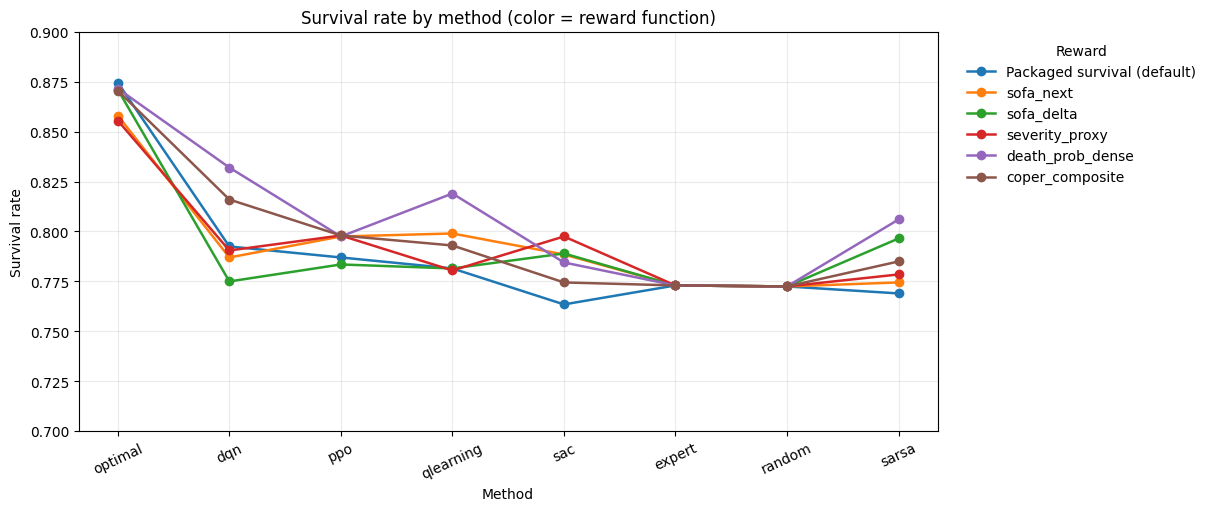

In [10]:
import matplotlib.pyplot as plt

if "summary_df" not in globals():
    raise RuntimeError("Run the combined table cell first to create summary_df.")

plot_df = summary_df.copy()
policy_order = ["optimal", "dqn", "ppo", "qlearning", "sac", "expert", "random", "sarsa"]
reward_order = [
    "Packaged survival (default)",
    "sofa_next",
    "sofa_delta",
    "severity_proxy",
    "death_prob_dense",
    "coper_composite",
]

plot_df["policy"] = pd.Categorical(plot_df["policy"], categories=policy_order, ordered=True)
plot_df["reward"] = pd.Categorical(plot_df["reward"], categories=reward_order, ordered=True)
plot_df = plot_df.sort_values(["policy", "reward"])

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

for reward_name, group in plot_df.groupby("reward", observed=False):
    if group["survival_rate"].notna().any():
        ax.plot(
            group["policy"],
            group["survival_rate"],
            marker="o",
            linewidth=1.8,
            label=str(reward_name),
        )

ax.set_title("Survival rate by method (color = reward function)")
ax.set_xlabel("Method")
ax.set_ylabel("Survival rate")
ax.set_ylim(0.70, 0.90)
ax.tick_params(axis="x", rotation=25)
ax.grid(alpha=0.25)
ax.legend(title="Reward", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.show()

### Policy preview (state → recommended action)

Table over the **first transient states**: **optimal** action (value iteration on the **packaged** reward of the loaded MDP) vs **clinical mode** (most frequent action, `argmax` on `expert_policy[s]`).

Run at least the **first code cell** (imports + helpers). Long training sections are **not** required for this table.

In [11]:
from IPython.display import display

_ref = gym.make("Sepsis/ICU-Sepsis-v2")
_mdp = _ref.unwrapped
_tx = np.asarray(_mdp.dynamics["tx_mat"])
_r0 = np.asarray(_mdp.dynamics["r_mat"])
_gamma = float(_mdp.gamma)
_expert = np.asarray(_mdp.expert_policy)
_sofa = np.asarray(_mdp.sofa_scores).ravel()
_n_states = int(_mdp.num_states)
_n_actions = int(_mdp.num_actions)
_levels = int(round(np.sqrt(_n_actions)))
_ref.close()

_opt, _ = value_iteration(_tx, _r0, _gamma)
n_tr = _n_states - 3

def _dec(a: int) -> tuple[int, int]:
    return int(a // _levels), int(a % _levels)

rows = []
for s in range(min(15, n_tr)):
    a_opt = int(_opt[s])
    p = _expert[s].astype(float)
    a_exp = int(np.argmax(p))
    fo, vo = _dec(a_opt)
    fe, ve = _dec(a_exp)
    rows.append(
        {
            "state": s,
            "cluster_mean_SOFA": float(_sofa[s]),
            "a_opt": a_opt,
            "fluid_opt": fo,
            "vaso_opt": vo,
            "a_clin_mode": a_exp,
            "fluid_clin": fe,
            "vaso_clin": ve,
            "P_clinical(a_opt)": float(p[a_opt]) if p.sum() > 0 else 0.0,
        }
    )

display(pd.DataFrame(rows))

Value Iteration:   0%|          | 149/50000 [00:06<37:14, 22.31it/s]


,state,cluster_mean_SOFA,a_opt,fluid_opt,vaso_opt,a_clin_mode,fluid_clin,vaso_clin,P_clinical(a_opt)
0,0,5.485955,20,4,0,5,1,0,0.087079
1,1,4.596847,0,0,0,0,0,0,0.954955
2,2,2.831368,5,1,0,15,3,0,0.070755
3,3,2.988688,15,3,0,5,1,0,0.194570
4,4,13.433260,20,4,0,20,4,0,0.177243
5,5,6.040580,0,0,0,0,0,0,0.979710
6,6,10.484594,10,2,0,15,3,0,0.271709
7,7,4.157233,5,1,0,5,1,0,0.425577
8,8,5.795699,0,0,0,0,0,0,0.964158
9,9,8.064877,10,2,0,5,1,0,0.239374


### Gap: optimal policy vs clinical policy (most different actions)

For each transient state `s`, compare **VI** action `a_opt(s)` with the **clinical mode** `a_clin(s) = argmax_a π_exp(a|s)`.

**Distance used:** Manhattan distance on **decoded intensity levels** (fluid and vasopressor in `{0,…,4}`), i.e. `|f_opt - f_clin| + |v_opt - v_clin|`. Rows with largest distance are most divergent **on this discrete treatment grid** (not a distance in mL or µg/kg/min).

**One-step terminal masses** from the tabular dynamics `T(s'|s,a)`: `P_one_step_survival_*` is the probability of transitioning to the **hospital survival** absorbing state in **one** step under that action; `P_one_step_death_*` is the same for **death**. These are *not* discounted multi-step survival—just the immediate next-state distribution under the fitted MDP.

**State detail:** `cluster_mean_SOFA` is the asset’s per-state SOFA average; `centroid_*` are selected **normalized** cluster-center coordinates; `centroid_top5_abs` lists the five largest-|value| feature dimensions (interpretation: same as `icu_sepsis_demo` section on centroids).

In [17]:
_ref = gym.make("Sepsis/ICU-Sepsis-v2")
_mdp = _ref.unwrapped
_tx = np.asarray(_mdp.dynamics["tx_mat"])
_r0 = np.asarray(_mdp.dynamics["r_mat"])
_gamma = float(_mdp.gamma)
_expert = np.asarray(_mdp.expert_policy)
_sofa = np.asarray(_mdp.sofa_scores).ravel()
_centers = np.asarray(_mdp.state_cluster_centers)
_n_states = int(_mdp.num_states)
_n_actions = int(_mdp.num_actions)
_levels = int(round(np.sqrt(_n_actions)))
_s_death = int(_mdp.state_death)
_s_surv = int(_mdp.state_survival)
_ref.close()

_opt, _ = value_iteration(_tx, _r0, _gamma)
n_tr = _n_states - 3

_FEATURE_NAMES = (
    ["gender", "mechvent", "max_dose_vaso", "re_admission"]
    + [
        "age", "Weight_kg", "GCS", "HR", "SysBP", "MeanBP", "DiaBP",
        "RR", "Temp_C", "FiO2_1", "Potassium", "Sodium", "Chloride",
        "Glucose", "Magnesium", "Calcium", "Hb", "WBC_count",
        "Platelets_count", "PTT", "PT", "Arterial_pH", "paO2", "paCO2",
        "Arterial_BE", "HCO3", "Arterial_lactate", "SOFA", "SIRS",
        "Shock_Index", "PaO2_FiO2", "cumulated_balance",
    ]
    + [
        "SpO2", "BUN", "Creatinine", "SGOT", "SGPT", "Total_bili", "INR",
        "input_total", "input_4hourly", "output_total", "output_4hourly",
    ]
)
if _centers.shape[1] != len(_FEATURE_NAMES):
    _FEATURE_NAMES = [f"f_{j}" for j in range(_centers.shape[1])]
_fn_idx = {n: i for i, n in enumerate(_FEATURE_NAMES)}


def _dec(a: int) -> tuple[int, int]:
    return int(a // _levels), int(a % _levels)


def _centroid_topk_str(row: np.ndarray, k: int = 5) -> str:
    v = np.asarray(row, dtype=float).ravel()
    k = min(k, len(v))
    order = np.argsort(-np.abs(v))[:k]
    return "; ".join(f"{_FEATURE_NAMES[i]}={v[i]:.3f}" for i in order)


def _cent_val(row: np.ndarray, name: str) -> float:
    j = _fn_idx.get(name)
    if j is None:
        return float("nan")
    return float(np.asarray(row, dtype=float).ravel()[j])


diff_rows = []
for s in range(n_tr):
    a_o = int(_opt[s])
    a_c = int(np.argmax(_expert[s]))
    fo, vo = _dec(a_o)
    fc, vc = _dec(a_c)
    manh = abs(fo - fc) + abs(vo - vc)
    ps_o = float(_tx[s, a_o, _s_surv])
    ps_c = float(_tx[s, a_c, _s_surv])
    pd_o = float(_tx[s, a_o, _s_death])
    pd_c = float(_tx[s, a_c, _s_death])
    crow = _centers[s]
    diff_rows.append(
        {
            "state": s,
            "cluster_mean_SOFA": float(_sofa[s]),
            "centroid_SOFA": _cent_val(crow, "SOFA"),
            "centroid_HR": _cent_val(crow, "HR"),
            "centroid_MeanBP": _cent_val(crow, "MeanBP"),
            "centroid_Arterial_lactate": _cent_val(crow, "Arterial_lactate"),
            "centroid_top5_abs": _centroid_topk_str(crow, k=5),
            "manhattan_levels": manh,
            "a_opt": a_o,
            "fluid_opt": fo,
            "vaso_opt": vo,
            "a_clin_mode": a_c,
            "fluid_clin": fc,
            "vaso_clin": vc,
            "P_one_step_survival_opt": ps_o,
            "P_one_step_survival_clin": ps_c,
            "P_one_step_survival_delta_opt_minus_clin": ps_o - ps_c,
            "P_one_step_death_opt": pd_o,
            "P_one_step_death_clin": pd_c,
        }
    )

diff_df = pd.DataFrame(diff_rows).sort_values(
    ["manhattan_levels", "cluster_mean_SOFA"], ascending=[False, False]
)
_col_order = [
    "state",
    "cluster_mean_SOFA",
    "centroid_SOFA",
    "centroid_HR",
    "centroid_MeanBP",
    "centroid_Arterial_lactate",
    "centroid_top5_abs",
    "manhattan_levels",
    "a_opt",
    "fluid_opt",
    "vaso_opt",
    "a_clin_mode",
    "fluid_clin",
    "vaso_clin",
    "P_one_step_survival_opt",
    "P_one_step_survival_clin",
    "P_one_step_survival_delta_opt_minus_clin",
    "P_one_step_death_opt",
    "P_one_step_death_clin",
]
diff_df = diff_df[[c for c in _col_order if c in diff_df.columns]]

print(
    "Top 20 states — largest VI vs clinical-mode gap. "
    "P_one_step_survival_* = tabular T(s'|s,a) mass on the hospital-survival absorbing state "
    f"(index {_s_surv}); P_one_step_death_* uses death index {_s_death}. "
    "Centroid columns are normalized K-means features (same scale as the MDP build)."
)
display(diff_df.head(20))

print(
    "\nDistribution of Manhattan gaps (L1 on decoded fluid/vaso levels in {0,…,4}; "
    "max = 8). Missing levels are omitted by plain value_counts(); table below shows 0..8 explicitly."
)
_gap_counts = diff_df["manhattan_levels"].value_counts().reindex(range(9), fill_value=0).rename("count")
display(_gap_counts)

_xlsx_dir = PROJECT_ROOT / "results" / "demo_outputs" / "reward_functions"
_xlsx_dir.mkdir(parents=True, exist_ok=True)
_state_diff_xlsx = _xlsx_dir / "state_diff.xlsx"
with pd.ExcelWriter(_state_diff_xlsx, engine="openpyxl") as _xw:
    diff_df.to_excel(_xw, sheet_name="state_diff", index=False)
    _gap_counts.rename_axis("manhattan_levels").reset_index().to_excel(
        _xw, sheet_name="manhattan_gaps", index=False
    )
print(f"Wrote {_state_diff_xlsx.resolve()}")

Value Iteration:   0%|          | 149/50000 [00:06<38:25, 21.62it/s]

Top 20 states — largest VI vs clinical-mode gap. P_one_step_survival_* = tabular T(s'|s,a) mass on the hospital-survival absorbing state (index 714); P_one_step_death_* uses death index 713. Centroid columns are normalized K-means features (same scale as the MDP build).


,state,cluster_mean_SOFA,centroid_SOFA,centroid_HR,centroid_MeanBP,centroid_Arterial_lactate,centroid_top5_abs,manhattan_levels,a_opt,fluid_opt,vaso_opt,a_clin_mode,fluid_clin,vaso_clin,P_one_step_survival_opt,P_one_step_survival_clin,P_one_step_survival_delta_opt_minus_clin,P_one_step_death_opt,P_one_step_death_clin
63,63,17.531250,3.087941,1.652600,-1.019632,10.291401,Arterial_lactate=10.291; SGOT=3.840; SOFA=3.08...,8,0,0,0,24,4,4,0.000000,0.000000,0.000000,0.166667,0.166667
562,562,17.446927,3.280135,1.126574,-1.103759,4.060220,Arterial_lactate=4.060; SOFA=3.280; INR=2.329;...,8,0,0,0,24,4,4,0.016393,0.016393,0.000000,0.049180,0.049180
27,27,16.313953,2.904482,0.495293,-1.427013,5.929340,SpO2=-10.596; Arterial_lactate=5.929; SOFA=2.9...,8,0,0,0,24,4,4,0.000000,0.000000,0.000000,0.218750,0.218750
256,256,14.769231,2.904482,0.885880,-1.317928,5.260010,Arterial_lactate=5.260; Glucose=4.645; PTT=3.9...,8,0,0,0,24,4,4,0.000000,0.000000,0.000000,0.214286,0.214286
583,583,14.181818,2.294808,1.579077,-0.499784,0.701735,WBC_count=4.354; SOFA=2.295; Shock_Index=2.215...,8,0,0,0,24,4,4,0.020833,0.020833,0.000000,0.041667,0.041667
246,246,14.135593,2.129330,-0.451206,-1.078603,5.074114,Arterial_lactate=5.074; Arterial_pH=-3.303; SG...,8,0,0,0,24,4,4,0.000000,0.000000,0.000000,0.171429,0.171429
525,525,13.088889,2.117046,1.643563,-0.660181,4.150722,Glucose=4.760; Arterial_lactate=4.151; Arteria...,8,0,0,0,24,4,4,0.000000,0.000000,0.000000,0.111111,0.111111
615,615,12.208589,1.801880,1.373808,-0.710247,0.817933,PTT=5.073; Shock_Index=2.115; input_4hourly=1....,8,0,0,0,24,4,4,0.000000,0.000000,0.000000,0.034483,0.034483
299,299,11.941176,1.407899,0.304870,-1.116353,7.398380,Arterial_lactate=7.398; Arterial_BE=-2.652; Ar...,8,0,0,0,24,4,4,0.000000,0.000000,0.000000,0.071429,0.071429
423,423,6.178571,-0.017555,0.277742,2.870593,-0.103033,cumulated_balance=3.935; MeanBP=2.871; Platele...,8,0,0,0,24,4,4,0.076923,0.076923,0.000000,0.000000,0.000000



Distribution of Manhattan gaps (L1 on decoded fluid/vaso levels in {0,…,4}; max = 8). Missing levels are omitted by plain value_counts(); table below shows 0..8 explicitly.


manhattan_levels
0    211
1    250
2    131
3     99
4      9
5      2
6      1
7      0
8     10
Name: count, dtype: int64

Wrote /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/results/demo_outputs/reward_functions/state_diff.xlsx


### Clinician-oriented view: **state** (cluster profile)

For a transient state index `s`, we show the cluster **centroid**: values live in the **preprocessed** space (centering / z-score / log+z-score as in the RL build), not raw chart units. They are still useful to **compare relative patterns** across states.

Edit `EXAMPLE_STATES` (integers `< num_states - 3`).

In [13]:
_ref = gym.make("Sepsis/ICU-Sepsis-v2")
_mdp = _ref.unwrapped
_centers = np.asarray(_mdp.state_cluster_centers)
_sofa = np.asarray(_mdp.sofa_scores).ravel()
_n_states = int(_mdp.num_states)
_ref.close()

FEATURE_NAMES = (
    ["gender", "mechvent", "max_dose_vaso", "re_admission"]
    + [
        "age", "Weight_kg", "GCS", "HR", "SysBP", "MeanBP", "DiaBP",
        "RR", "Temp_C", "FiO2_1", "Potassium", "Sodium", "Chloride",
        "Glucose", "Magnesium", "Calcium", "Hb", "WBC_count",
        "Platelets_count", "PTT", "PT", "Arterial_pH", "paO2", "paCO2",
        "Arterial_BE", "HCO3", "Arterial_lactate", "SOFA", "SIRS",
        "Shock_Index", "PaO2_FiO2", "cumulated_balance",
    ]
    + [
        "SpO2", "BUN", "Creatinine", "SGOT", "SGPT", "Total_bili", "INR",
        "input_total", "input_4hourly", "output_total", "output_4hourly",
    ]
)
if _centers.shape[1] != len(FEATURE_NAMES):
    FEATURE_NAMES = [f"f_{j}" for j in range(_centers.shape[1])]

EXAMPLE_STATES = [0, 1, 2, int(_sofa[: _n_states - 3].argmax())]

n_tr = _n_states - 3
for s in EXAMPLE_STATES:
    if s < 0 or s >= n_tr:
        continue
    ser = pd.Series(_centers[s], index=FEATURE_NAMES, name=f"state_{s}")
    top = ser.reindex(ser.abs().sort_values(ascending=False).head(15).index)
    print(f"\n=== State s={s} | cluster mean SOFA = {_sofa[s]:.2f} ===")
    display(top.to_frame("value (normalized centroid)"))


=== State s=0 | cluster mean SOFA = 5.49 ===


,value (normalized centroid)
SGOT,2.463198
SGPT,2.358372
HCO3,1.501865
Chloride,-1.143157
FiO2_1,0.858086
input_4hourly,0.836091
SpO2,-0.656168
re_admission,0.587805
PaO2_FiO2,-0.531628
output_total,0.512081



=== State s=1 | cluster mean SOFA = 4.60 ===


,value (normalized centroid)
input_4hourly,-2.938938
Glucose,2.759183
Chloride,-0.724092
FiO2_1,-0.575876
GCS,0.564711
DiaBP,-0.564187
SOFA,-0.541538
Total_bili,-0.528638
re_admission,0.507080
max_dose_vaso,-0.496115



=== State s=2 | cluster mean SOFA = 2.83 ===


,value (normalized centroid)
age,-1.790403
input_4hourly,1.671364
BUN,-1.400121
Hb,1.029266
SIRS,-1.001447
SOFA,-0.968218
RR,-0.721207
Creatinine,-0.659251
HR,-0.649972
output_4hourly,0.624636



=== State s=607 | cluster mean SOFA = 18.02 ===


,value (normalized centroid)
SOFA,3.541366
Calcium,2.657767
Total_bili,2.594466
INR,2.027540
PT,1.804944
GCS,-1.771325
input_4hourly,1.673865
output_4hourly,-1.451384
Chloride,-1.319940
Arterial_lactate,1.233478


### Clinician-oriented view: **action** (IV fluids × vasopressors)

An **action** is an integer `a` encoding two **integer intensity levels** on an `n×n` grid (usually **n = 5**):

- `fluid_level = a // n`
- `vaso_level = a % n`

These levels are **not** mL or µg/kg/min in the notebook: they come from **rank-based quantile bins** on the training cohort, computed **separately for strictly positive administrations**; level **0** means **no administration** (no fluid / no vasopressor) on that modeled timestep. See `get_action_nums` in `icu_sepsis_helpers/mdp_creation/create_rl_table.py` (`input_4hourly` and `max_dose_vaso`).

In [14]:
_ref = gym.make("Sepsis/ICU-Sepsis-v2")
_mdp = _ref.unwrapped
_tx = np.asarray(_mdp.dynamics["tx_mat"])
_r0 = np.asarray(_mdp.dynamics["r_mat"])
_gamma = float(_mdp.gamma)
_expert = np.asarray(_mdp.expert_policy)
_n_actions = int(_mdp.num_actions)
_levels = int(round(np.sqrt(_n_actions)))
_ref.close()

_opt, _ = value_iteration(_tx, _r0, _gamma)

LABELS = {
    "fluid": "input_4hourly (4h IV input, raw MIMIC column)",
    "vaso": "max_dose_vaso (max vasopressor dose in window, raw column)",
}


def explain_action(a: int) -> pd.DataFrame:
    a = int(a)
    f, v = int(a // _levels), int(a % _levels)
    rows = [
        ("index_action_a", a),
        ("grid", f"{_levels} levels × {_levels} levels = {_n_actions} actions"),
        ("fluid_level (0 = no IV fluid)", f),
        ("vaso_level (0 = no vasopressor)", v),
        (LABELS["fluid"], "rank-quantile bins on values > 0 → 0..4"),
        (LABELS["vaso"], "rank-quantile bins on values > 0 → 0..4"),
    ]
    return pd.DataFrame(rows, columns=["field", "value"])


# Same example states as the "state" cell above — compare optimal vs clinical mode
EXAMPLE_STATES = [0, 1, 2]
for s in EXAMPLE_STATES:
    if s >= len(_opt) - 3:
        break
    a_o = int(_opt[s])
    a_c = int(np.argmax(_expert[s]))
    print(f"\n=== State s={s} | optimal action (VI) a={a_o} ===")
    display(explain_action(a_o))
    print(f"=== Same state | clinical mode a={a_c} (argmax π_exp(·|s)) ===")
    display(explain_action(a_c))
    p_on_opt = float(_expert[s, a_o])
    print(f"P_clinical(a_opt | s={s}) = {p_on_opt:.4f}\n")

Value Iteration:   0%|          | 149/50000 [00:06<37:31, 22.14it/s]


=== State s=0 | optimal action (VI) a=20 ===


,field,value
0,index_action_a,20
1,grid,5 levels × 5 levels = 25 actions
2,fluid_level (0 = no IV fluid),4
3,vaso_level (0 = no vasopressor),0
4,"input_4hourly (4h IV input, raw MIMIC column)",rank-quantile bins on values > 0 → 0..4
5,"max_dose_vaso (max vasopressor dose in window,...",rank-quantile bins on values > 0 → 0..4


=== Same state | clinical mode a=5 (argmax π_exp(·|s)) ===


,field,value
0,index_action_a,5
1,grid,5 levels × 5 levels = 25 actions
2,fluid_level (0 = no IV fluid),1
3,vaso_level (0 = no vasopressor),0
4,"input_4hourly (4h IV input, raw MIMIC column)",rank-quantile bins on values > 0 → 0..4
5,"max_dose_vaso (max vasopressor dose in window,...",rank-quantile bins on values > 0 → 0..4


...

P_clinical(a_opt | s=1) = 0.9550


=== State s=2 | optimal action (VI) a=5 ===


,field,value
0,index_action_a,5
1,grid,5 levels × 5 levels = 25 actions
2,fluid_level (0 = no IV fluid),1
3,vaso_level (0 = no vasopressor),0
4,"input_4hourly (4h IV input, raw MIMIC column)",rank-quantile bins on values > 0 → 0..4
5,"max_dose_vaso (max vasopressor dose in window,...",rank-quantile bins on values > 0 → 0..4


=== Same state | clinical mode a=15 (argmax π_exp(·|s)) ===


,field,value
0,index_action_a,15
1,grid,5 levels × 5 levels = 25 actions
2,fluid_level (0 = no IV fluid),3
3,vaso_level (0 = no vasopressor),0
4,"input_4hourly (4h IV input, raw MIMIC column)",rank-quantile bins on values > 0 → 0..4
5,"max_dose_vaso (max vasopressor dose in window,...",rank-quantile bins on values > 0 → 0..4


P_clinical(a_opt | s=2) = 0.0708

